# 라운드L/라운드W와 같이 가중치 갱신 변화량등 내가 살펴보기위해 계산그래프 출력해보는 연습

In [5]:
# ===============================
# 1. 기본 라이브러리
# ===============================
import torch
import torch.nn as nn
import torch.optim as optim

# ===============================
# 2. 학습 데이터 (XOR 문제)
# ===============================
X = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
])

y = torch.tensor([
    [0.],
    [1.],
    [1.],
    [0.]
])

# ===============================
# 3. 2-2-1 MLP 정의
# ===============================
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 2),
            nn.ReLU(),
            nn.Linear(2, 1),
            nn.Sigmoid()   # 0~1 출력
        )

    def forward(self, x):
        return self.net(x)

model = MLP()

# ===============================
# 4. 손실함수 & 옵티마이저
# ===============================
criterion = nn.BCELoss()   # 이진 분류
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ===============================
# 5. 학습 루프
# ===============================
for epoch in range(2000):
    optimizer.zero_grad()

    output = model(X)
    loss = criterion(output, y)

    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"epoch {epoch}, loss {loss.item():.4f}")

# ===============================
# 6. 최종 예측 확인
# ===============================
print("\nFinal Output:")
print(model(X))

epoch 0, loss 0.6939
epoch 200, loss 0.6295
epoch 400, loss 0.5183
epoch 600, loss 0.4902
epoch 800, loss 0.4837
epoch 1000, loss 0.4810
epoch 1200, loss 0.4800
epoch 1400, loss 0.4793
epoch 1600, loss 0.4790
epoch 1800, loss 0.4788

Final Output:
tensor([[0.6651],
        [0.6651],
        [0.6651],
        [0.0041]], grad_fn=<SigmoidBackward0>)


In [6]:
output = model(X)
print(output.grad_fn)

x = model.net[0](X)
print(x.grad_fn)

In [7]:
pip install torchviz

  Using cached torchviz-0.0.3-py3-none-any.whl.metadata (2.1 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached torchviz-0.0.3-py3-none-any.whl (5.7 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchviz]
Note: you may need to restart the kernel to use updated packages.


In [17]:
from torchviz import make_dot

output = model(X)
dot = make_dot(output, params=dict(model.named_parameters()))
dot.render("mlp_graph", format="png")

'mlp_graph.png'

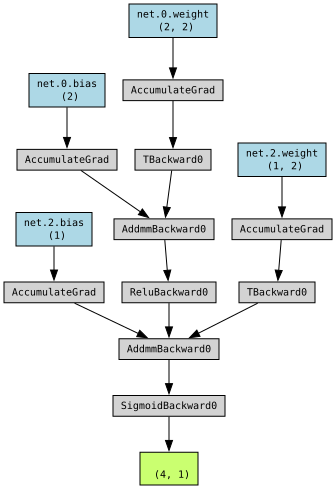

In [18]:
dot

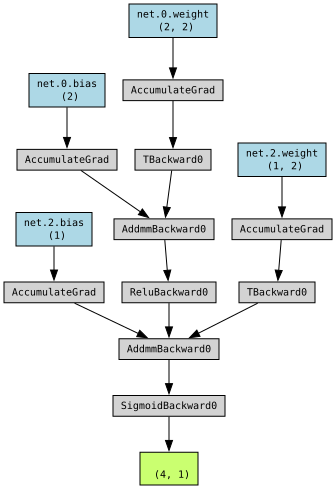

In [21]:
from torchviz import make_dot

output = model(X)
dot = make_dot(output, params=dict(model.named_parameters())) # 파라미터 위치 알려주는 코드
dot

In [10]:
from torch.fx import symbolic_trace

traced = symbolic_trace(model)
print(traced.graph)

graph():
    %x : [num_users=1] = placeholder[target=x]
    %net_0 : [num_users=1] = call_module[target=net.0](args = (%x,), kwargs = {})
    %net_1 : [num_users=1] = call_module[target=net.1](args = (%net_0,), kwargs = {})
    %net_2 : [num_users=1] = call_module[target=net.2](args = (%net_1,), kwargs = {})
    %net_3 : [num_users=1] = call_module[target=net.3](args = (%net_2,), kwargs = {})
    return net_3


In [11]:
pip install tensorboard

  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
Using cached tensorboard_data_server-0.7.2-py3-none-any.whl (2.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 31.7 MB/s  0:00:00.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [tensorboard] 6/7 [tensorboard]o]
Note: you may need to restart the kernel to use updated packages.


In [13]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter()

dummy_input = torch.randn(1, 2)
writer.add_graph(model, dummy_input)

writer.close()

# 내 맥북 전용 GPU활용해보기

In [2]:
# 우선 gpu(MPS)사용가능함 확인

import torch
print(torch.__version__)
print("MPS available:", torch.backends.mps.is_available())

2.10.0
MPS available: True


In [ ]:
## CPU와 GPU 동일한 연산으로 실행시간 비교해보기

In [3]:
import torch
import time

size = 3000  # 1000이면 차이 거의 안 날 수 있음. 3000~5000 추천.

# -------------------
# CPU 테스트
# -------------------
start = time.time()

x_cpu = torch.randn(size, size)
y_cpu = torch.matmul(x_cpu, x_cpu)

cpu_time = time.time() - start
print(f"CPU time: {cpu_time:.4f} seconds")


CPU time: 0.1631 seconds


In [4]:
# -------------------
# MPS(GPU) 테스트
# -------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")

    start = time.time()

    x_gpu = torch.randn(size, size).to(device)
    y_gpu = torch.matmul(x_gpu, x_gpu)

    # MPS는 비동기라서 동기화 필요
    torch.mps.synchronize()

    gpu_time = time.time() - start
    print(f"MPS time: {gpu_time:.4f} seconds")

    print(f"Speedup (CPU / MPS): {cpu_time / gpu_time:.2f}x")

else:
    print("MPS not available")

MPS time: 0.4375 seconds
Speedup (CPU / MPS): 0.37x


In [ ]:
'''
위 결과를 보면 연산이 작아서 그런지 gpu가 더 느렸다 이제 8000정도로 늘려서 연산을 크게해서 비교해보자
'''

In [15]:
import torch
import time

size = 8000  # 1000이면 차이 거의 안 날 수 있음. 3000~5000 추천.

# -------------------
# CPU 테스트
# -------------------
start = time.time()

x_cpu = torch.randn(size, size)
y_cpu = torch.matmul(x_cpu, x_cpu)

cpu_time = time.time() - start
print(f"CPU time: {cpu_time:.4f} seconds")


CPU time: 1.2215 seconds


In [16]:
# -------------------
# MPS(GPU) 테스트
# -------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")

    start = time.time()

    x_gpu = torch.randn(size, size).to(device)
    y_gpu = torch.matmul(x_gpu, x_gpu)

    # MPS는 비동기라서 동기화 필요
    torch.mps.synchronize()

    gpu_time = time.time() - start
    print(f"MPS time: {gpu_time:.4f} seconds")

    print(f"Speedup (CPU / MPS): {cpu_time / gpu_time:.2f}x")

else:
    print("MPS not available")

MPS time: 0.9011 seconds
Speedup (CPU / MPS): 1.36x


In [ ]:
'''
확인완료 연산을 키우니 확실히 gpu가 빠르다 (위에서 테스트 해본 연산은 행렬의 곱셈연산으로 병렬처리가 빠른 gpu가 유리함을 확인해보는 문제이다.)
'''